In [32]:
import wrds
import pandas as pd

In [36]:
#You can enter your own user name
# 
# --- User Login Section ---
# Prompt the user to enter their WRDS username
# The default example 'neymar' is kept in the prompt text for reference
username = input("Please enter your WRDS username (e.g.,neymar): ")

# Establish the connection using the input variable
# Note: You might be prompted for your password in the terminal or browser depending on your setup
db = wrds.Connection(wrds_username=username)

print(f"\nSuccessfully connected to WRDS as user: {username}")



Please enter your WRDS username (e.g.,neymar):  neymar


Loading library list...
Done

Successfully connected to WRDS as user: neymar


In [34]:
#Making preparations for the followings 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

In [44]:
# 1. Get user input
user_tickers = input("Please enter company stock codes (separated by commas, e.g., AAPL,MSFT):): ").upper()
user_indfmt = input("Please enter INDFMT (e.g., INDL): ").upper()

# 2. Process the input to add quotes for SQL
# If user types "AAPL,MSFT", this converts it to "'AAPL','MSFT'"
# We split the string by comma, strip whitespace, wrap in quotes, and join back.
formatted_tickers = ",".join([f"'{t.strip()}'" for t in user_tickers.split(",")])

# 3. Construct the SQL query using an f-string
sql = f"""
    SELECT 
        tic, 
        fyear, 
        sale, 
        ni, 
        at, 
        ceq,
        act,   
        lct  
    FROM 
        comp.funda
    WHERE 
        tic IN ({formatted_tickers})
        AND fyear BETWEEN 2020 AND 2024
        AND indfmt = '{user_indfmt}' 
        AND datafmt = 'STD' 
        AND popsrc = 'D' 
        AND consol = 'C'
    ORDER BY 
        tic, fyear
    """
    
# 4. Execute and print
df = db.raw_sql(sql, coerce_float=True)
print("Executing the following SQL query:")
print(sql)
print("\nQuery result preview:")
print(df.head())

Please enter company stock codes (separated by commas, e.g., AAPL,MSFT):):  NVDA
Please enter INDFMT (e.g., INDL):  INDL


Executing the following SQL query:

    SELECT 
        tic, 
        fyear, 
        sale, 
        ni, 
        at, 
        ceq,
        act,   
        lct  
    FROM 
        comp.funda
    WHERE 
        tic IN ('NVDA')
        AND fyear BETWEEN 2020 AND 2024
        AND indfmt = 'INDL' 
        AND datafmt = 'STD' 
        AND popsrc = 'D' 
        AND consol = 'C'
    ORDER BY 
        tic, fyear
    

Query result preview:
    tic  fyear      sale       ni        at      ceq      act      lct
0  NVDA   2020   16675.0   4332.0   28791.0  16893.0  16055.0   3925.0
1  NVDA   2021   26914.0   9752.0   44187.0  26612.0  28829.0   4335.0
2  NVDA   2022   26974.0   4368.0   41182.0  22101.0  23073.0   6563.0
3  NVDA   2023   60922.0  29760.0   65728.0  42978.0  44345.0  10631.0
4  NVDA   2024  130497.0  72880.0  111601.0  79327.0  80126.0  18047.0


In [58]:
# --- USER INPUT SECTION ---
# Ask the user for up to 3 company tickers
user_input = input("Please enter up to 3 company stock codes (separated by commas, e.g., AAPL,MSFT,GOOGL): ").upper()
user_indfmt = input("Please enter INDFMT (e.g., INDL): ").upper()
#  Process the input to add quotes for SQL
# If user types "AAPL,MSFT", this converts it to "'AAPL','MSFT'"
# We split the string by comma, strip whitespace, wrap in quotes, and join back.
formatted_tickers = ",".join([f"'{t.strip()}'" for t in user_tickers.split(",")])
# Construct the SQL query using an f-string
sql = f"""
    SELECT 
        tic, 
        fyear, 
        sale, 
        ni, 
        at, 
        ceq,
        act,   
        lct  
    FROM 
        comp.funda
    WHERE 
        tic IN ({formatted_tickers})
        AND fyear BETWEEN 2020 AND 2024
        AND indfmt = '{user_indfmt}' 
        AND datafmt = 'STD' 
        AND popsrc = 'D' 
        AND consol = 'C'
    ORDER BY 
        tic, fyear
    """

# Split the input string into a list and clean up any extra spaces
# Example: "aapl, msft" -> ['AAPL', 'MSFT']
selected_tickers = [t.strip() for t in user_input.split(',')]

# Limit to the first 3 valid entries just in case the user types more
selected_tickers = selected_tickers[:3]

print(f"\nYou have selected the following companies for analysis: {selected_tickers}")
print("-" * 50)

# --- DATA CLEANING & CALCULATION ---

# 1. Data Cleaning
# Keep only the necessary columns and drop rows with any missing values
cols_needed = ['tic', 'fyear', 'sale', 'ni', 'at', 'ceq', 'act', 'lct']
clean_data = raw_data[cols_needed].dropna()

# 2. Calculate Financial Ratios
# Note: We multiply by 100 to convert to percentage format for easier visualization
clean_data['net_margin'] = (clean_data['ni'] / clean_data['sale']) * 100
clean_data['roa'] = (clean_data['ni'] / clean_data['at']) * 100
clean_data['current_ratio'] = clean_data['act'] / clean_data['lct']
clean_data['roe'] = (clean_data['ni'] / clean_data['ceq']) * 100
clean_data['revenue_growth_growth'] = clean_data.groupby('tic')['sale'].pct_change() * 100

# Group by fiscal year (fyear) and calculate the mean for all companies
industry_data = clean_data.groupby('fyear')[['net_margin', 'roa', 'current_ratio', 'roe', 'revenue_growth_growth']].mean().reset_index()

# Add a 'tic' column to the industry data with the value 'Industry'
industry_data['tic'] = 'Industry'

# Concatenate the original data with the industry average data
clean_data = pd.concat([clean_data, industry_data], ignore_index=True)

# --- DYNAMIC REPORTING SECTION ---

# Define the columns we want to display in the final output
display_cols = ['tic', 'fyear', 'net_margin', 'roa', 'roe', 'current_ratio', 'revenue_growth_growth']

# Loop through each ticker the user selected and print the data
for ticker in selected_tickers:
    # Filter data for the specific ticker
    company_data = clean_data[clean_data['tic'] == ticker]
    
    # Check if data exists for this ticker to avoid errors
    if not company_data.empty:
        print(f"First 5 rows of data for {ticker}:")
        print(company_data[display_cols].head())
        print("\n" + "="*50 + "\n") # Print a separator line
    else:
        print(f"No data found for {ticker}. Please check the ticker symbol.")
        print("\n" + "="*50 + "\n")

Please enter up to 3 company stock codes (separated by commas, e.g., AAPL,MSFT,GOOGL):  AAPL,NVDA
Please enter INDFMT (e.g., INDL):  INDL



You have selected the following companies for analysis: ['AAPL', 'NVDA']
--------------------------------------------------
First 5 rows of data for AAPL:
    tic  fyear  net_margin        roa         roe  current_ratio  \
0  AAPL   2020   20.913611  17.725572   87.866359       1.363604   
1  AAPL   2021   25.881793  26.974205  150.071327       1.074553   
2  AAPL   2022   25.309641  28.292441  196.958873       0.879356   
3  AAPL   2023   25.306234  27.509835  156.076015       0.988012   
4  AAPL   2024   23.971256  25.682503  164.593503       0.867313   

   revenue_growth_growth  
0                   <NA>  
1              33.259385  
2               7.793788  
3              -2.800461  
4               2.021994  


First 5 rows of data for NVDA:
    tic  fyear  net_margin        roa        roe  current_ratio  \
5  NVDA   2020    25.97901  15.046369  25.643758       4.090446   
6  NVDA   2021    36.23393   22.06984  36.645123       6.650288   
7  NVDA   2022   16.193371  10.606576  

In [61]:
# --- STEP 1: GET INPUT & DOWNLOAD DATA ---

# 1. Get user input for tickers
user_indfmt = input("Please enter INDFMT (e.g., INDL): ").upper()
user_input = input("Please enter up to 2 company stock codes (separated by commas, e.g., AAPL,MSFT,NVDA): ").upper()
selected_tickers = [t.strip() for t in user_input.split(',')]
selected_tickers = selected_tickers[:2] # Limit to 2

# 2. Format tickers for SQL (add quotes)
# e.g., ['NVDA', 'AAPL'] becomes "'NVDA','AAPL'"
formatted_tickers = ",".join([f"'{t}'" for t in selected_tickers])

# 3. Construct SQL query dynamically
# We use {formatted_tickers} to insert the user's choice directly into the query
sql = f"""
    SELECT 
        tic, 
        fyear, 
        sale, 
        ni, 
        at, 
        ceq,
        act,   
        lct  
    FROM 
        comp.funda
    WHERE 
        tic IN ({formatted_tickers})  -- This line now changes based on input!
        AND fyear BETWEEN 2020 AND 2024
        AND indfmt ='{user_indfmt}' 
        AND datafmt = 'STD' 
        AND popsrc = 'D' 
        AND consol = 'C'
    ORDER BY 
        tic, fyear
    """
    
# 4. Execute the query to populate raw_data
print(f"Downloading data for: {selected_tickers}...")
raw_data = db.raw_sql(sql, coerce_float=True)

# Check if we actually got data back
if raw_data.empty:
    print("No data found in the database for these tickers. Please check the symbols or database connection.")
else:
    print("Data download successful.")
    # You can now proceed with the cleaning/calculation code you provided earlier...

Please enter INDFMT (e.g., INDL):  INDL
Please enter up to 2 company stock codes (separated by commas, e.g., AAPL,MSFT,NVDA):  AAPL,MSFT


Data download successful.


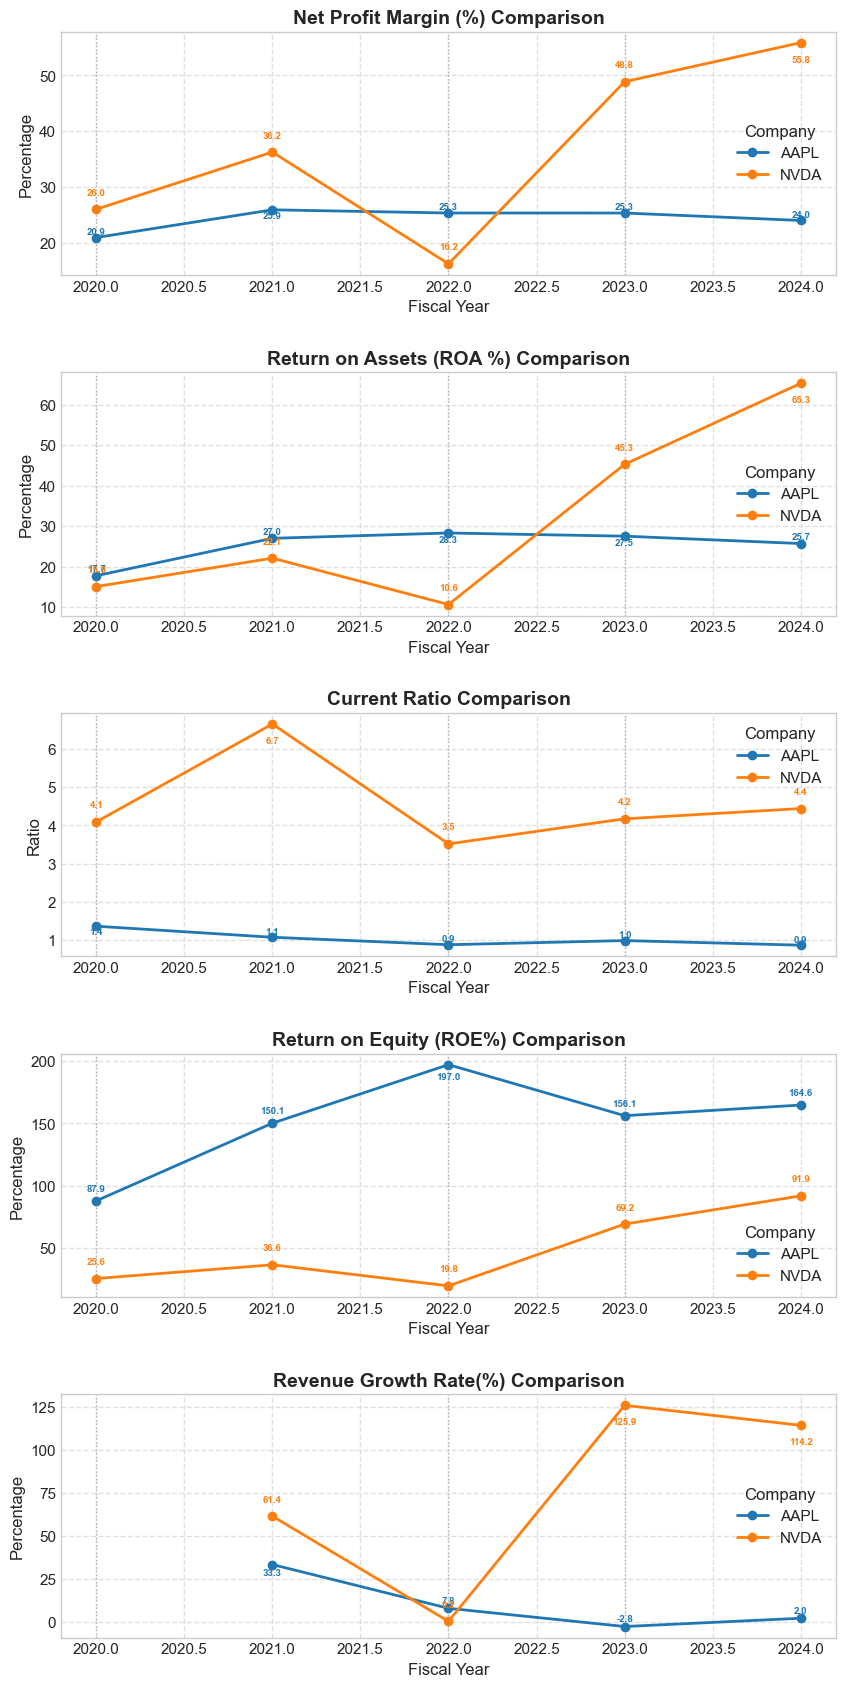

🎉 Visualization complete!


In [59]:
# --- PREPARE DYNAMIC COLORS ---
# We create a color palette. If the user picks more companies than colors, 
# this cycle will repeat colors.
default_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
# Create a dictionary mapping each selected ticker to a color
colors = {ticker: default_colors[i % len(default_colors)] for i, ticker in enumerate(selected_tickers)}

# --- PLOTTING SETUP ---
plt.style.use('seaborn-v0_8-whitegrid')

# Create canvas
fig, axes = plt.subplots(5, 1, figsize=(10, 22))

# Define metrics
metrics = [
    ('net_margin', 'Net Profit Margin (%)', 'Percentage'),
    ('roa', 'Return on Assets (ROA %)', 'Percentage'),
    ('current_ratio', 'Current Ratio', 'Ratio'),
    ('roe','Return on Equity (ROE%)', 'Percentage'),
    ('revenue_growth_growth','Revenue Growth Rate(%)','Percentage')
]


# Loop through plots
for i, (metric, title, ylabel) in enumerate(metrics):
    ax = axes[i]
    
    # 1. Draw the lines and Smart Labeling
    # CHANGE: Loop through 'selected_tickers' instead of hardcoded ['AAPL', 'MSFT']
    for company in selected_tickers:
        company_data = clean_data[clean_data['tic'] == company]
        
        # Skip if this company has no data (prevents errors)
        if company_data.empty:
            continue
            
        # --- Plot the actual line ---
        ax.plot(company_data['fyear'], company_data[metric], 
                color=colors[company], label=company, linewidth=2, marker='o')
        
        # --- Smart Labeling ---
        for x, y in zip(company_data['fyear'], company_data[metric]):
            if pd.notna(y):
                label_text = f"{y:.1f}"
                
                ymin, ymax = ax.get_ylim()
                y_range = ymax - ymin
                 
                if y_range == 0:
                    y_range = 1
                    
                offset_amount = y_range * 0.05 
                
                if y >= 0:
                    text_y = y + offset_amount
                    va_align = 'bottom'
                else:
                    text_y = y - offset_amount
                    va_align = 'top'
                
                y_rel = (y - ymin) / y_range
                if y_rel > 0.85:
                    text_y = y - offset_amount
                    va_align = 'top'
                elif y_rel < 0.15:
                    text_y = y + offset_amount
                    va_align = 'bottom'
                
                ax.text(x, text_y, label_text, 
                        fontsize=7, color=colors[company], 
                        ha='center', va=va_align, fontweight='bold')

    # 2. Smart Event Annotation
    for year, label in events_raw:
        ax.axvline(x=year, color='gray', linestyle=':', linewidth=1, alpha=0.5)
        
        
    # Set titles and labels
    ax.set_title(f'{title} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel('Fiscal Year', fontsize=12)
    
    ax.legend(title='Company')
    ax.grid(True, linestyle='--', alpha=0.6)

# Adjust layout
plt.subplots_adjust(bottom=0.15, hspace=0.4)

# Show plot
plt.show()

print("🎉 Visualization complete!")